# Telecom Customer Churn Analysis

**Portfolio-ready Python Data Analytics project**

This notebook complements the **MySQL + Power BI** telecom churn project.

### Objectives
- Validate the 7,043-row telecom customer dataset.
- Profile and document missing values instead of silently dropping customers.
- Create business-friendly churn and tenure fields.
- Explore churn drivers using clear visualizations.
- Calculate churn and observed revenue KPIs.
- Build a Logistic Regression baseline as an optional predictive extension.
- Produce reusable CSV outputs for documentation/GitHub.

> **Important:** Revenue KPIs use the observed `MonthlyCharges` values. Missing monthly charges are not imputed for revenue reporting because doing so would change the financial totals. Imputation is used only inside the ML pipeline.


In [1]:
# ============================================================
# 0. PROJECT SETUP
# ============================================================
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay, roc_curve
)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
RANDOM_STATE = 42

# ------------------------------------------------------------
# Portable project-root detection
# Project structure:
# 01_Dataset / 02-SQL / 03_PowerBI / 04_Python / 05_Documentation
# ------------------------------------------------------------
def find_project_root(start_path=None):
    start = Path(start_path or Path.cwd()).resolve()

    candidates = [start] + list(start.parents)

    for candidate in candidates:
        dataset_file = candidate / "01_Dataset" / "telco_data.csv"
        if dataset_file.exists():
            return candidate

    # Fallback when the dataset is not available yet.
    for candidate in candidates:
        if (candidate / "01_Dataset").is_dir() and (candidate / "04_Python").is_dir():
            return candidate

    # Last-resort fallback: assume this notebook/script is in 04_Python.
    if start.name == "04_Python":
        return start.parent

    return start


PROJECT_DIR = find_project_root()

OUTPUT_DIR = PROJECT_DIR / "04_Python" / "outputs"

KPI_DIR = OUTPUT_DIR / "KPI"
CHART_DIR = OUTPUT_DIR / "Charts"
SEGMENT_DIR = OUTPUT_DIR / "Segment_Analysis"
MODEL_DIR = OUTPUT_DIR / "Model"
DATA_QUALITY_DIR = OUTPUT_DIR / "Data_Quality"
INSIGHTS_DIR = OUTPUT_DIR / "Insights"

for folder in [
    KPI_DIR,
    CHART_DIR,
    SEGMENT_DIR,
    MODEL_DIR,
    DATA_QUALITY_DIR,
    INSIGHTS_DIR
]:
    folder.mkdir(parents=True, exist_ok=True)

DATA_PATH = PROJECT_DIR / "01_Dataset" / "telco_data.csv"

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found.\nExpected location:\n{DATA_PATH}\n\n"
        "Place telco_data.csv in 01_Dataset and run the notebook again."
    )

print("Project folder:", PROJECT_DIR)
print("Dataset path:", DATA_PATH)
print("Output folder:", OUTPUT_DIR)


Project folder: C:\Users\Kaushlendra P Singh\Documents\Telecom-Customer-Churn-Analysis
Dataset path: C:\Users\Kaushlendra P Singh\Documents\Telecom-Customer-Churn-Analysis\01_Dataset\telco_data.csv
Output folder: C:\Users\Kaushlendra P Singh\Documents\Telecom-Customer-Churn-Analysis\04_Python\outputs


## 1. Load dataset


In [2]:
df_raw = pd.read_csv(DATA_PATH)


In [3]:
# Display basic information

print(f"Rows: {len(df_raw):,}")
print(f"Columns: {df_raw.shape[1]}")
display(df_raw.head())


Rows: 7,043
Columns: 21


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1.0,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34.0,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2.0,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45.0,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2.0,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
print(df_raw.info())

quality_report = pd.DataFrame({
    "dtype": df_raw.dtypes.astype(str),
    "missing_count": df_raw.isna().sum(),
    "missing_pct": (df_raw.isna().mean() * 100).round(2),
    "unique_values": df_raw.nunique(dropna=True)
}).sort_values("missing_count", ascending=False)

display(quality_report[quality_report["missing_count"] > 0])

print("Duplicate customer IDs:", df_raw["customerID"].duplicated().sum())
display(df_raw["Churn"].value_counts(dropna=False).rename_axis("Churn").to_frame("Customers"))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            6293 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           6043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            4543 non-null   float64
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   6043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       5543 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,dtype,missing_count,missing_pct,unique_values
tenure,float64,2500,35.50,73
StreamingTV,object,1500,21.30,3
MonthlyCharges,float64,1500,21.30,1489
InternetService,object,1000,14.20,3
Partner,object,1000,14.20,2
gender,object,750,10.65,2


Duplicate customer IDs: 0


,Customers
Churn,
No,5174
Yes,1869


## 2. Data Cleaning & Feature Engineering

The raw file contains missing values in several fields. Rather than dropping hundreds/thousands of rows, the analysis layer:
- keeps all 7,043 customer records;
- converts numeric fields safely;
- labels missing categorical values as `Unknown`;
- creates `SeniorCitizenLabel`;
- creates four business-friendly tenure cohorts;
- creates binary `is_churned`.

This preserves the original customer population for descriptive analysis.


In [5]:
# ============================================================
# 2. DATA CLEANING & FEATURE ENGINEERING
# ============================================================

df = df_raw.copy()

# ------------------------------------------------------------
# Convert numeric columns
# ------------------------------------------------------------

for col in ["tenure", "MonthlyCharges", "TotalCharges"]:
    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )


# ------------------------------------------------------------
# Fill missing categorical values
# ------------------------------------------------------------

for col in df.select_dtypes(include="object").columns:

    if col != "customerID":
        df[col] = df[col].fillna("Unknown")


# ------------------------------------------------------------
# Senior Citizen Label
# ------------------------------------------------------------

df["SeniorCitizenLabel"] = (
    df["SeniorCitizen"]
    .map({
        0: "Non-Senior",
        1: "Senior"
    })
    .fillna("Unknown")
)


# ------------------------------------------------------------
# Tenure Cohort
#
# Missing tenure is retained as "Unknown".
# We do NOT silently impute tenure for descriptive
# business analysis.
# ------------------------------------------------------------

df["TenureCohort"] = pd.cut(
    df["tenure"],
    bins=[-np.inf, 12, 24, 48, np.inf],
    labels=[
        "0-12 Months",
        "13-24 Months",
        "25-48 Months",
        "Over 48 Months"
    ],
    include_lowest=True
)

df["TenureCohort"] = (
    df["TenureCohort"]
    .astype("object")
    .fillna("Unknown")
)


# ------------------------------------------------------------
# Binary churn flag
# ------------------------------------------------------------

df["is_churned"] = (
    df["Churn"]
    .astype(str)
    .str.strip()
    .str.lower()
    .eq("yes")
    .astype(int)
)


# ------------------------------------------------------------
# Basic validation
# ------------------------------------------------------------

print("Final analysis rows:", len(df))

print("\nMissing values:")
display(
    df.isnull().sum()
    .loc[lambda x: x > 0]
)

print("\nTenure Cohort distribution:")
display(
    df["TenureCohort"]
    .value_counts(dropna=False)
)

display(df.head())


Final analysis rows: 7043

Missing values:


tenure            2500
MonthlyCharges    1500
TotalCharges        11
dtype: int64


Tenure Cohort distribution:


TenureCohort
Unknown           2500
Over 48 Months    1445
0-12 Months       1402
25-48 Months      1049
13-24 Months       647
Name: count, dtype: int64

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,SeniorCitizenLabel,TenureCohort,is_churned
0,7590-VHVEG,Female,0,Yes,No,1.0,No,No phone service,DSL,No,...,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,Non-Senior,0-12 Months,0
1,5575-GNVDE,Male,0,No,No,34.0,Yes,No,DSL,Yes,...,No,One year,No,Mailed check,56.95,1889.50,No,Non-Senior,25-48 Months,0
2,3668-QPYBK,Male,0,No,No,2.0,Yes,No,DSL,Yes,...,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,Non-Senior,0-12 Months,1
3,7795-CFOCW,Male,0,No,No,45.0,No,No phone service,DSL,Yes,...,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,Non-Senior,25-48 Months,0
4,9237-HQITU,Female,0,No,No,2.0,Yes,No,Fiber optic,No,...,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,Non-Senior,0-12 Months,1


In [6]:
#checking missing value
print("\nMissing values:")
print(df.isnull().sum())



Missing values:
customerID               0
gender                   0
SeniorCitizen            0
Partner                  0
Dependents               0
tenure                2500
PhoneService             0
MultipleLines            0
InternetService          0
OnlineSecurity           0
OnlineBackup             0
DeviceProtection         0
TechSupport              0
StreamingTV              0
StreamingMovies          0
Contract                 0
PaperlessBilling         0
PaymentMethod            0
MonthlyCharges        1500
TotalCharges            11
Churn                    0
SeniorCitizenLabel       0
TenureCohort             0
is_churned               0
dtype: int64


In [7]:
# If you want to see percentage of missing values
missing_percent = df.isnull().mean() * 100
print(missing_percent[missing_percent > 0])


tenure            35.496237
MonthlyCharges    21.297742
TotalCharges       0.156183
dtype: float64


In [8]:
# chang datatype
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors= 'coerce')


In [9]:
# Check how many NaNs appeared after conversion
print(df['TotalCharges'].isnull().sum())


11


## 3. Core Business KPIs


In [10]:
total_customers = len(df)
churned_customers = int(df["is_churned"].sum())
churn_rate = churned_customers / total_customers * 100

# Do not impute MonthlyCharges for revenue KPIs.
observed_monthly_revenue = df["MonthlyCharges"].sum(min_count=1)
churned_monthly_revenue = df.loc[df["is_churned"].eq(1), "MonthlyCharges"].sum(min_count=1)
revenue_at_risk_pct = churned_monthly_revenue / observed_monthly_revenue * 100

kpis = pd.DataFrame({
    "KPI": [
        "Total Customers",
        "Churned Customers",
        "Churn Rate %",
        "Observed Monthly Revenue",
        "Churned Monthly Revenue",
        "Revenue at Risk %"
    ],
    "Value": [
        total_customers,
        churned_customers,
        round(churn_rate, 2),
        round(observed_monthly_revenue, 2),
        round(churned_monthly_revenue, 2),
        round(revenue_at_risk_pct, 2)
    ]
})

display(kpis)
kpis.to_csv(KPI_DIR / "business_kpis.csv", index=False)


,KPI,Value
0,Total Customers,7043.00
1,Churned Customers,1869.00
2,Churn Rate %,26.54
3,Observed Monthly Revenue,359609.90
4,Churned Monthly Revenue,109419.65
5,Revenue at Risk %,30.43


In [11]:
df.describe()


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,is_churned
count,7043.000000,4543.000000,5543.000000,7032.000000,7043.000000
mean,0.162147,32.546555,64.876403,2283.300441,0.265370
std,0.368612,24.505519,30.101331,2266.771362,0.441561
min,0.000000,0.000000,18.250000,18.800000,0.000000
25%,0.000000,9.000000,35.750000,401.450000,0.000000
50%,0.000000,29.000000,70.550000,1397.475000,0.000000
75%,0.000000,56.000000,89.925000,3794.737500,1.000000
max,1.000000,72.000000,118.600000,8684.800000,1.000000


## 4. Exploratory Data Analysis


Saved to: C:\Users\Kaushlendra P Singh\Documents\Telecom-Customer-Churn-Analysis\04_Python\outputs\Charts\01_churn_distribution.png


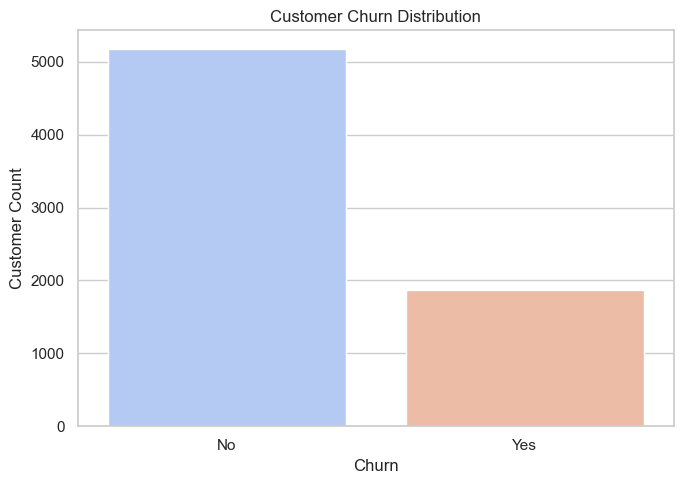

In [12]:
# Countplot for Churn distribution

plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="Churn", hue="Churn", legend=False, palette = 'coolwarm')
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Customer Count")
plt.tight_layout()
plt.savefig(CHART_DIR / "01_churn_distribution.png", dpi=300, bbox_inches='tight')
print("Saved to:", str(CHART_DIR / "01_churn_distribution.png"))
plt.show()

Saved to: C:\Users\Kaushlendra P Singh\Documents\Telecom-Customer-Churn-Analysis\04_Python\outputs\Charts\02_Tenure_distribution.png


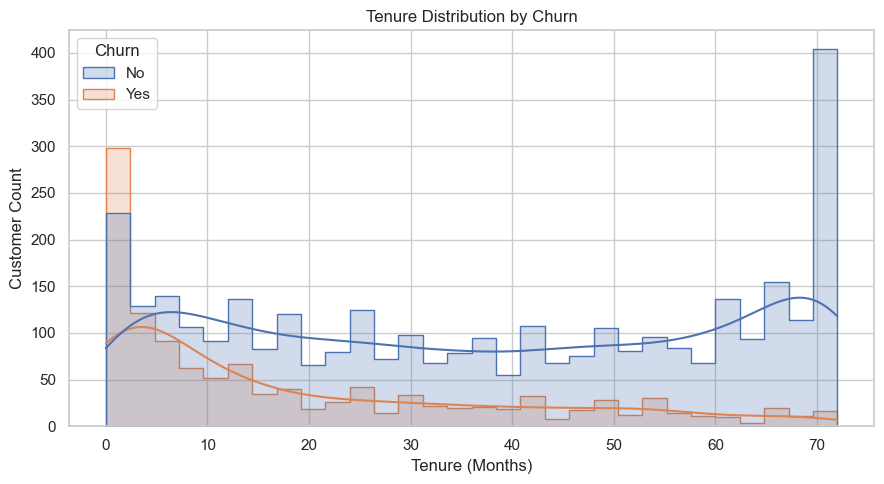

In [13]:
# histplot for Tenure Distribution by Churn

plt.figure(figsize=(9, 5))
sns.histplot(
    data=df[df["tenure"].notna()],
    x="tenure",
    hue="Churn",
    bins=30,
    kde=True,
    element="step",
    stat="count"
)
plt.title("Tenure Distribution by Churn")
plt.xlabel("Tenure (Months)")
plt.ylabel("Customer Count")
plt.tight_layout()
plt.savefig(CHART_DIR / "02_Tenure_distribution.png", dpi=300, bbox_inches='tight')
print("Saved to:", str(CHART_DIR / "02_Tenure_distribution.png"))
plt.show()


Saved to: C:\Users\Kaushlendra P Singh\Documents\Telecom-Customer-Churn-Analysis\04_Python\outputs\Charts\03_Monthly_Charges_vs_Churn.png


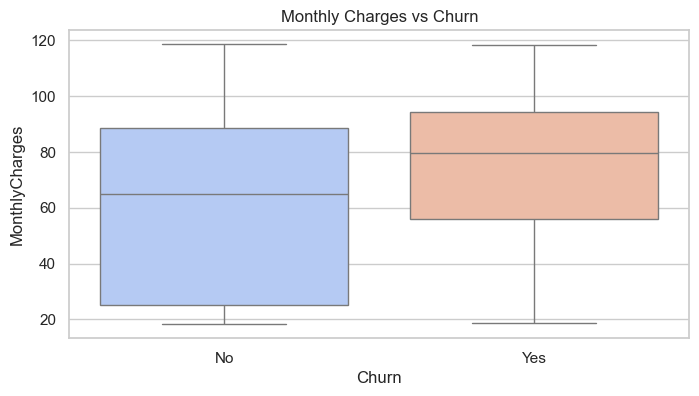

In [14]:
# Boxplot for Monthly Charges vs Churn

plt.figure(figsize= (8,4))
sns.boxplot(x= 'Churn', y= 'MonthlyCharges', data=df, palette = 'coolwarm')
plt.title('Monthly Charges vs Churn')
plt.savefig(CHART_DIR / "03_Monthly_Charges_vs_Churn.png", dpi=300, bbox_inches='tight')
print("Saved to:", str(CHART_DIR / "03_Monthly_Charges_vs_Churn.png"))
plt.show()


* Customers with higher monthly charges show higher observed churn in this dataset.


Saved to: C:\Users\Kaushlendra P Singh\Documents\Telecom-Customer-Churn-Analysis\04_Python\outputs\Charts\04_Contract_Type_vs_Churn.png


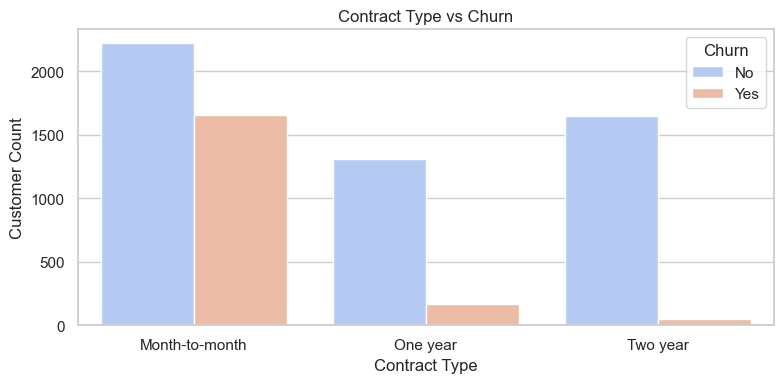

In [15]:
#Countplot for Contract Type vs Churn

plt.figure(figsize= (8,4))
sns.countplot(x='Contract', hue= 'Churn', data= df, palette='coolwarm')
plt.title('Contract Type vs Churn')
plt.xlabel("Contract Type")
plt.ylabel("Customer Count")
plt.tight_layout()
plt.savefig(CHART_DIR / "04_Contract_Type_vs_Churn.png", dpi=300, bbox_inches='tight')
print("Saved to:", str(CHART_DIR / "04_Contract_Type_vs_Churn.png"))
plt.show()


* Customers on month to month is more contracts churn more than those on longterm contracts


Saved to: C:\Users\Kaushlendra P Singh\Documents\Telecom-Customer-Churn-Analysis\04_Python\outputs\Charts\05_Customer_Count_by_Gender_and_Churn.png


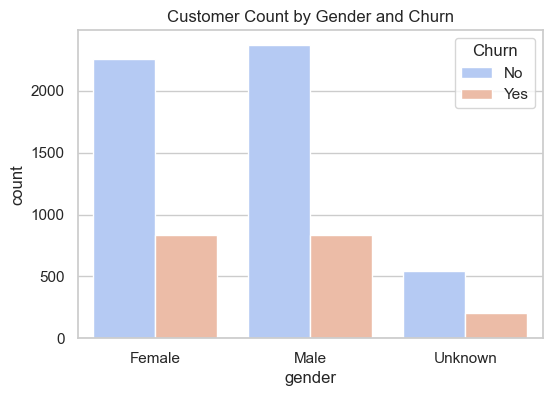

In [16]:
# Countplot Churn rate by Gender

plt.figure(figsize= (6,4))
sns.countplot(x= 'gender', hue= 'Churn', data= df, palette= 'coolwarm')
plt.title('Customer Count by Gender and Churn')
plt.savefig(CHART_DIR / "05_Customer_Count_by_Gender_and_Churn.png", dpi=300, bbox_inches='tight')
print("Saved to:", str(CHART_DIR / "05_Customer_Count_by_Gender_and_Churn.png"))
plt.show()


### Insight

* If the bars for Male and Female are similar, gender doesn’t influence churn.
* If there’s a difference, we may need to consider it as a feature.


Saved to: C:\Users\Kaushlendra P Singh\Documents\Telecom-Customer-Churn-Analysis\04_Python\outputs\Charts\06_Churn_rate_by_Senior_Citizen.png


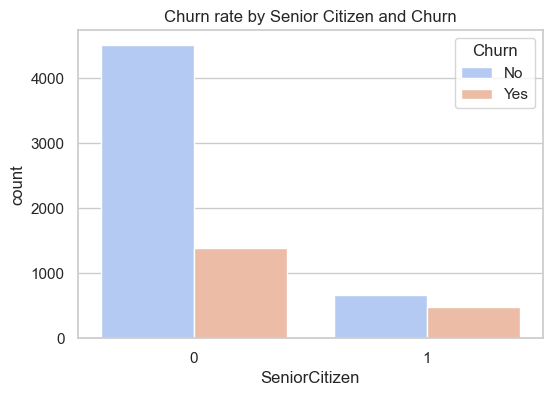

In [17]:
# Countplot Churn rate by Senior Citizen

plt.figure(figsize= (6,4))
sns.countplot(x= 'SeniorCitizen', hue= 'Churn', data= df, palette= 'coolwarm')
plt.title('Churn rate by Senior Citizen and Churn')
plt.savefig(CHART_DIR / "06_Churn_rate_by_Senior_Citizen.png", dpi=300, bbox_inches='tight')
print("Saved to:", str(CHART_DIR / "06_Churn_rate_by_Senior_Citizen.png"))
plt.show()


### Insight:

* If senior citizens have a higher churn rate, they may need better retention strategies.


Saved to: C:\Users\Kaushlendra P Singh\Documents\Telecom-Customer-Churn-Analysis\04_Python\outputs\Charts\07_Churn_rate_by_Internet_service.png


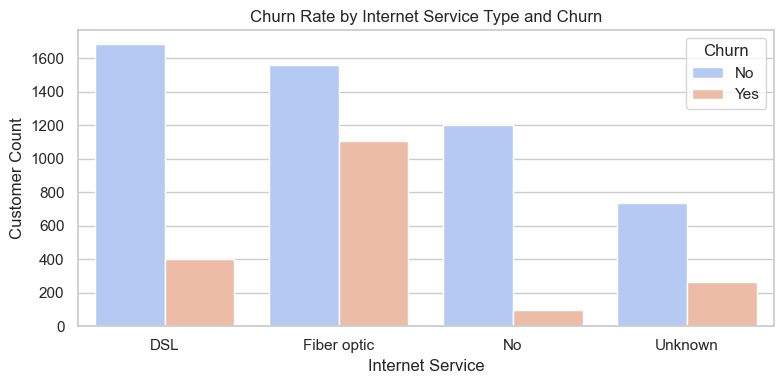

In [18]:
# Churn by Internet Service Type
plt.figure(figsize=(8,4))
sns.countplot(x='InternetService', hue='Churn', data=df, palette='coolwarm')
plt.title('Churn Rate by Internet Service Type and Churn')
plt.xlabel("Internet Service")
plt.ylabel("Customer Count")
plt.tight_layout()
plt.savefig(CHART_DIR / "07_Churn_rate_by_Internet_service.png", dpi=300, bbox_inches='tight')
print("Saved to:", str(CHART_DIR / "07_Churn_rate_by_Internet_service.png"))
plt.show()


Saved to: C:\Users\Kaushlendra P Singh\Documents\Telecom-Customer-Churn-Analysis\04_Python\outputs\Charts\08_Churn_rate_by_Payment_Method_and_Churn.png


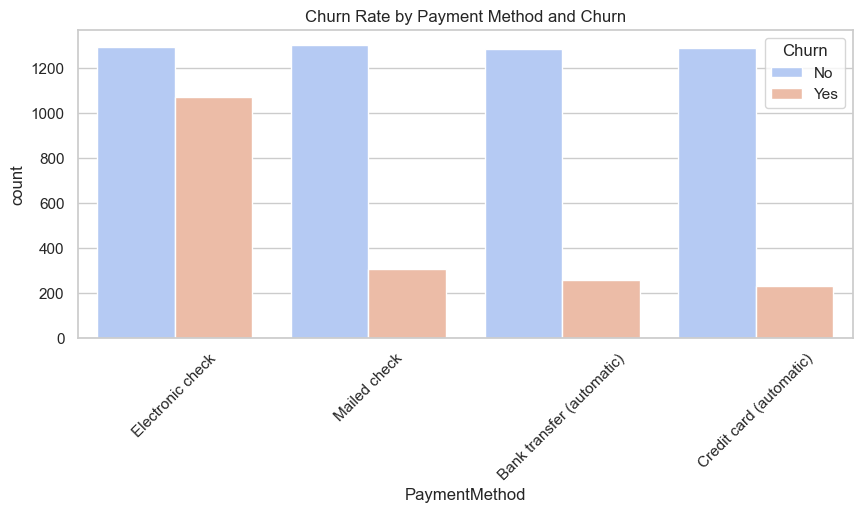

In [19]:
# Payment Method & Churn
plt.figure(figsize=(10,4))
sns.countplot(x='PaymentMethod', hue='Churn', data=df, palette='coolwarm')
plt.xticks(rotation=45)
plt.title('Churn Rate by Payment Method and Churn')
plt.savefig(CHART_DIR / "08_Churn_rate_by_Payment_Method_and_Churn.png", dpi=300, bbox_inches='tight')
print("Saved to:", str(CHART_DIR / "08_Churn_rate_by_Payment_Method_and_Churn.png"))
plt.show()

Saved to: C:\Users\Kaushlendra P Singh\Documents\Telecom-Customer-Churn-Analysis\04_Python\outputs\Charts\09_Tenure_&_Monthly_Charges_vs_Churn.png


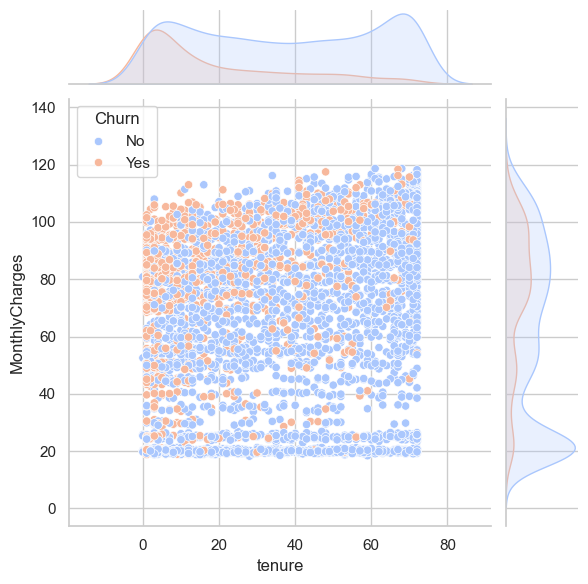

In [20]:
# Tenure & Monthly Charges vs Churn (Jointplot Analysis)
sns.jointplot(x='tenure', y='MonthlyCharges', hue='Churn', data=df, kind="scatter", palette='coolwarm')
plt.savefig(CHART_DIR / "09_Tenure_&_Monthly_Charges_vs_Churn.png", dpi=300, bbox_inches='tight')
print("Saved to:", str(CHART_DIR / "09_Tenure_&_Monthly_Charges_vs_Churn.png"))
plt.show()

### Insight:

* Short-tenure, high-charges customers churn the most.

* Short-tenure customers with higher monthly charges show elevated churn exposure in the dataset.


In [21]:
# ============================================================
# FUNCTION: CHURN RATE BY SEGMENT
# ============================================================

def churn_rate_table(data, segment_column):
    """
    Return a standardized churn-rate table for one business segment.

    Output columns:
    - segment
    - total_customers
    - churned_customers
    - churn_rate
    """
    if segment_column not in data.columns:
        raise KeyError(f"Column '{segment_column}' was not found in the DataFrame.")

    temp = data.copy()

    # Use the prepared numeric churn flag when available.
    if "is_churned" in temp.columns:
        temp["_churn_flag"] = pd.to_numeric(
            temp["is_churned"], errors="coerce"
        ).fillna(0).astype(int)

    elif "Churn" in temp.columns:
        temp["_churn_flag"] = (
            temp["Churn"]
            .astype(str)
            .str.strip()
            .str.lower()
            .map({"yes": 1, "no": 0, "1": 1, "0": 0})
            .fillna(0)
            .astype(int)
        )

    else:
        raise ValueError(
            "Neither 'is_churned' nor 'Churn' column was found."
        )

    result = (
        temp.groupby(segment_column, dropna=False)
        .agg(
            total_customers=("_churn_flag", "size"),
            churned_customers=("_churn_flag", "sum")
        )
        .reset_index()
        .rename(columns={segment_column: "segment"})
    )

    result["churn_rate"] = (
        result["churned_customers"]
        / result["total_customers"]
        * 100
    ).round(2)

    return result.sort_values(
        "churn_rate",
        ascending=False,
        ignore_index=True
    )


In [22]:
test_result = churn_rate_table(
    df,
    "Contract"
)

display(test_result)


,segment,total_customers,churned_customers,churn_rate
0,Month-to-month,3875,1655,42.71
1,One year,1473,166,11.27
2,Two year,1695,48,2.83


,segment,total_customers,churned_customers,churn_rate
0,Electronic check,2365,1071,45.29
1,Mailed check,1612,308,19.11
2,Bank transfer (automatic),1544,258,16.71
3,Credit card (automatic),1522,232,15.24


Saved to: C:\Users\Kaushlendra P Singh\Documents\Telecom-Customer-Churn-Analysis\04_Python\outputs\Charts\09_churn_rate_by_payment_method.png


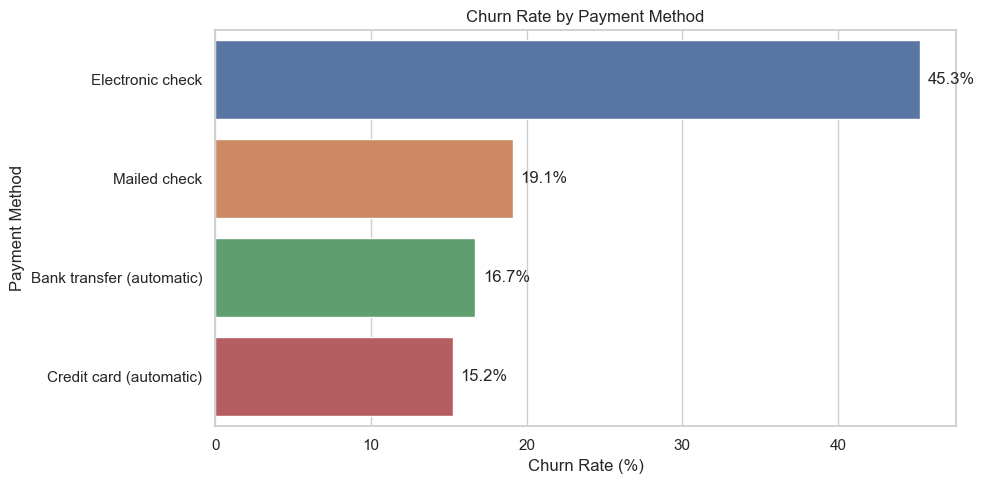

In [23]:
# ============================================================
# VISUAL: CHURN RATE BY PAYMENT METHOD
# ============================================================

payment = churn_rate_table(df, "PaymentMethod")
display(payment)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=payment,
    x="churn_rate",
    y="segment",
    hue="segment",
    legend=False
)

plt.title("Churn Rate by Payment Method")
plt.xlabel("Churn Rate (%)")
plt.ylabel("Payment Method")

for i, value in enumerate(payment["churn_rate"]):
    plt.text(value + 0.5, i, f"{value:.1f}%", va="center")

plt.tight_layout()

payment_chart_path = CHART_DIR / "09_churn_rate_by_payment_method.png"
plt.savefig(payment_chart_path, dpi=300, bbox_inches="tight")
print("Saved to:", payment_chart_path)

plt.show()
plt.close()


In [24]:
# ============================================================
# CHURN RATE BY TENURE COHORT
# ============================================================

tenure_churn = churn_rate_table(
    df,
    "TenureCohort"
)

display(tenure_churn)


,segment,total_customers,churned_customers,churn_rate
0,0-12 Months,1402,653,46.58
1,Unknown,2500,678,27.12
2,13-24 Months,647,169,26.12
3,25-48 Months,1049,222,21.16
4,Over 48 Months,1445,147,10.17


Saved to: C:\Users\Kaushlendra P Singh\Documents\Telecom-Customer-Churn-Analysis\04_Python\outputs\Charts\10_Churn_rate_by_Tenure_Cohort.png


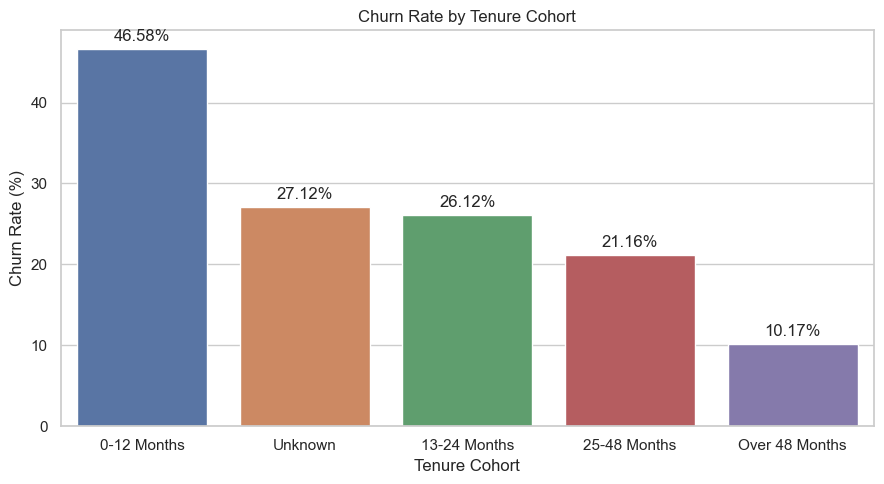

In [25]:
# ============================================================
# VISUAL: CHURN RATE BY TENURE COHORT
# ============================================================

plt.figure(figsize=(9, 5))

sns.barplot(
    data=tenure_churn,
    x="segment",
    y="churn_rate",
    hue="segment",
    legend=False
)

plt.title("Churn Rate by Tenure Cohort")
plt.xlabel("Tenure Cohort")
plt.ylabel("Churn Rate (%)")

for i, value in enumerate(tenure_churn["churn_rate"]):
    plt.text(
        i,
        value + 1,
        f"{value:.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.savefig(CHART_DIR / "10_Churn_rate_by_Tenure_Cohort.png", dpi=300, bbox_inches='tight')
print("Saved to:", str(CHART_DIR / "10_Churn_rate_by_Tenure_Cohort.png"))
plt.show()


In [26]:
# ============================================================
# CHURN RATE ANALYSIS BY BUSINESS SEGMENTS
# ============================================================

# Display names are kept separately from the actual DataFrame columns.

segment_map = {
    "Gender": "gender",
    "Partner": "Partner",
    "Dependents": "Dependents",
    "Senior Citizen": "SeniorCitizenLabel",
    "Tech Support": "TechSupport",
    "Online Security": "OnlineSecurity",
    "Online Backup": "OnlineBackup",
    "Internet Service": "InternetService",
    "Contract": "Contract",
    "Payment Method": "PaymentMethod",
    "Tenure Cohort": "TenureCohort"
}

segment_results = []

for segment_type, column_name in segment_map.items():

    if column_name not in df.columns:
        print(f"Skipping missing column: {column_name}")
        continue

    result = churn_rate_table(df, column_name)

    # Add the business-friendly dimension name.
    result.insert(0, "segment_type", segment_type)

    segment_results.append(result)

if not segment_results:
    raise ValueError("No segment columns were available for segment analysis.")

all_segment_results = pd.concat(
    segment_results,
    ignore_index=True
)

display(all_segment_results)


,segment_type,segment,total_customers,churned_customers,churn_rate
0,Gender,Unknown,750,207,27.60
1,Gender,Female,3091,831,26.88
2,Gender,Male,3202,831,25.95
3,Partner,No,3115,1022,32.81
4,Partner,Unknown,1000,265,26.50
5,Partner,Yes,2928,582,19.88
6,Dependents,No,4933,1543,31.28
7,Dependents,Yes,2110,326,15.45
8,Senior Citizen,Senior,1142,476,41.68
9,Senior Citizen,Non-Senior,5901,1393,23.61


In [27]:
# ============================================================
# VALIDATE STANDARDIZED SEGMENT RESULT
# ============================================================

required_segment_columns = [
    "segment_type",
    "segment",
    "total_customers",
    "churned_customers",
    "churn_rate"
]

missing_segment_columns = [
    col for col in required_segment_columns
    if col not in all_segment_results.columns
]

if missing_segment_columns:
    raise ValueError(
        "all_segment_results is missing required columns: "
        + ", ".join(missing_segment_columns)
    )

display(all_segment_results)

print(
    f"Segment analysis created successfully: "
    f"{len(all_segment_results):,} rows."
)


,segment_type,segment,total_customers,churned_customers,churn_rate
0,Gender,Unknown,750,207,27.60
1,Gender,Female,3091,831,26.88
2,Gender,Male,3202,831,25.95
3,Partner,No,3115,1022,32.81
4,Partner,Unknown,1000,265,26.50
5,Partner,Yes,2928,582,19.88
6,Dependents,No,4933,1543,31.28
7,Dependents,Yes,2110,326,15.45
8,Senior Citizen,Senior,1142,476,41.68
9,Senior Citizen,Non-Senior,5901,1393,23.61


Segment analysis created successfully: 35 rows.


In [28]:
# ============================================================
# EXPORT CHURN RATE BY BUSINESS SEGMENT
# ============================================================

segment_output_path = SEGMENT_DIR / "churn_rate_by_segment.csv"

all_segment_results.to_csv(
    segment_output_path,
    index=False
)

print("Saved:", segment_output_path)


Saved: C:\Users\Kaushlendra P Singh\Documents\Telecom-Customer-Churn-Analysis\04_Python\outputs\Segment_Analysis\churn_rate_by_segment.csv


In [29]:
# ============================================================
# EXPORT CHURN RATE BY TENURE COHORT
# ============================================================

tenure_output_path = SEGMENT_DIR / "churn_rate_by_tenure_cohort.csv"

tenure_churn.to_csv(
    tenure_output_path,
    index=False
)

print("Saved:", tenure_output_path)


Saved: C:\Users\Kaushlendra P Singh\Documents\Telecom-Customer-Churn-Analysis\04_Python\outputs\Segment_Analysis\churn_rate_by_tenure_cohort.csv


## 5. Churn Rate Analysis by Business Segment


In [30]:
# ============================================================
# BUSINESS SEGMENT SUMMARY
# ============================================================
# IMPORTANT:
# Do not redefine churn_rate_table() here.
# The canonical function is defined earlier in Cell 30.

for segment_type in segment_map.keys():
    part = all_segment_results[
        all_segment_results["segment_type"].eq(segment_type)
    ]

    if not part.empty:
        print(f"\n--- {segment_type} ---")
        display(part)



--- Gender ---


,segment_type,segment,total_customers,churned_customers,churn_rate
0,Gender,Unknown,750,207,27.60
1,Gender,Female,3091,831,26.88
2,Gender,Male,3202,831,25.95



--- Partner ---


,segment_type,segment,total_customers,churned_customers,churn_rate
3,Partner,No,3115,1022,32.81
4,Partner,Unknown,1000,265,26.50
5,Partner,Yes,2928,582,19.88



--- Dependents ---


...

,segment_type,segment,total_customers,churned_customers,churn_rate
23,Contract,Month-to-month,3875,1655,42.71
24,Contract,One year,1473,166,11.27
25,Contract,Two year,1695,48,2.83



--- Payment Method ---


,segment_type,segment,total_customers,churned_customers,churn_rate
26,Payment Method,Electronic check,2365,1071,45.29
27,Payment Method,Mailed check,1612,308,19.11
28,Payment Method,Bank transfer (automatic),1544,258,16.71
29,Payment Method,Credit card (automatic),1522,232,15.24



--- Tenure Cohort ---


,segment_type,segment,total_customers,churned_customers,churn_rate
30,Tenure Cohort,0-12 Months,1402,653,46.58
31,Tenure Cohort,Unknown,2500,678,27.12
32,Tenure Cohort,13-24 Months,647,169,26.12
33,Tenure Cohort,25-48 Months,1049,222,21.16
34,Tenure Cohort,Over 48 Months,1445,147,10.17


In [31]:
# ============================================================
# BUSINESS KPI OUTPUT
# ============================================================

total_customers = len(df)

if "is_churned" in df.columns:
    churned_customers = df["is_churned"].sum()

else:
    churned_customers = (
        df["Churn"]
        .astype(str)
        .str.strip()
        .str.lower()
        .eq("yes")
        .sum()
    )

churn_rate = (
    churned_customers
    / total_customers
    * 100
)

total_monthly_revenue = (
    pd.to_numeric(
        df["MonthlyCharges"],
        errors="coerce"
    ).sum()
    if "MonthlyCharges" in df.columns
    else pd.to_numeric(
        analysis_df["monthly_charges"],
        errors="coerce"
    ).sum()
)

if "is_churned" in df.columns:

    churned_monthly_revenue = (
        df.loc[
        df["is_churned"] == 1,
            "MonthlyCharges"
        ].sum()
        if "MonthlyCharges" in df.columns
        else analysis_df.loc[
            analysis_df["is_churned"] == 1,
            "monthly_charges"
        ].sum()
    )

else:

    churned_monthly_revenue = (
        df.loc[
            analysis_df["Churn"].astype(str).str.lower() == "yes",
            "MonthlyCharges"
        ].sum()
        if "MonthlyCharges" in df.columns
        else 0
    )

revenue_at_risk = (
    churned_monthly_revenue
    / total_monthly_revenue
    * 100
)

business_kpis = pd.DataFrame({
    "KPI": [
        "Total Customers",
        "Churned Customers",
        "Overall Churn Rate",
        "Total Monthly Revenue",
        "Churned Monthly Revenue",
        "Revenue at Risk"
    ],
    "Value": [
        total_customers,
        churned_customers,
        round(churn_rate, 2),
        round(total_monthly_revenue, 2),
        round(churned_monthly_revenue, 2),
        round(revenue_at_risk, 2)
    ]
})

display(business_kpis)



,KPI,Value
0,Total Customers,7043.00
1,Churned Customers,1869.00
2,Overall Churn Rate,26.54
3,Total Monthly Revenue,359609.90
4,Churned Monthly Revenue,109419.65
5,Revenue at Risk,30.43


In [32]:
business_kpis.to_csv(
    KPI_DIR / "business_kpis.csv",
    index=False
)

print("Saved business_kpis.csv")


Saved business_kpis.csv


## 6. Business Insights

Based on the descriptive analysis and calculated segment-level churn rates:

1. Overall churn is approximately **26.54%**, with 1,869 churned customers out of 7,043 customers.

2. **Month-to-month contract customers** show substantially higher churn than customers on one-year and two-year contracts.

3. The **0-12 month tenure cohort** has the highest observed churn rate among customers with known tenure.

4. **Fiber optic customers** show higher observed churn than DSL and customers without internet service.

5. **Electronic check** customers show the highest observed churn rate among the payment methods analyzed.

6. Customers without **Tech Support, Online Security, and Online Backup** show higher observed churn rates than customers with these services.

7. The dataset contains missing values in several fields. Missing tenure is retained as **Unknown** in the descriptive analysis rather than being silently assigned to a tenure cohort.

8. Churned customers contribute approximately **$109.42K in monthly charges**, representing approximately **30.43% of observed MonthlyCharges**.

9. These findings represent **associations in the historical dataset** and should not be interpreted as proof that a particular contract, service, payment method, or customer attribute causes churn.

10. The segment-level analysis can be used to identify customer groups that may warrant further retention analysis.


In [33]:
# ============================================================
# FINAL DATA QUALITY CHECK
# ============================================================

print("=" * 60)
print("FINAL PROJECT DATA QUALITY CHECK")
print("=" * 60)

print(f"\nTotal rows: {len(df):,}")
print(f"Total columns: {df.shape[1]}")

print(
    f"\nDuplicate customer IDs: "
    f"{df['customerID'].duplicated().sum():,}"
)

print("\nMissing values:")
display(
    df.isnull()
      .sum()
      .loc[lambda x: x > 0]
      .to_frame("Missing_Count")
)

print("\nTenure Cohort distribution:")
display(
    df["TenureCohort"]
    .value_counts(dropna=False)
)

print("\nContract churn:")
display(
    churn_rate_table(
        df,
        "Contract"
    )
)

print("\nTenure cohort churn:")
display(
    tenure_churn
)

print("\nFinal QA completed.")


FINAL PROJECT DATA QUALITY CHECK

Total rows: 7,043
Total columns: 24

Duplicate customer IDs: 0

Missing values:


,Missing_Count
tenure,2500
MonthlyCharges,1500
TotalCharges,11



Tenure Cohort distribution:


TenureCohort
Unknown           2500
Over 48 Months    1445
0-12 Months       1402
25-48 Months      1049
13-24 Months       647
Name: count, dtype: int64


Contract churn:


,segment,total_customers,churned_customers,churn_rate
0,Month-to-month,3875,1655,42.71
1,One year,1473,166,11.27
2,Two year,1695,48,2.83



Tenure cohort churn:


,segment,total_customers,churned_customers,churn_rate
0,0-12 Months,1402,653,46.58
1,Unknown,2500,678,27.12
2,13-24 Months,647,169,26.12
3,25-48 Months,1049,222,21.16
4,Over 48 Months,1445,147,10.17



Final QA completed.


In [34]:
# ============================================================
# EXPORT FINAL DATA QUALITY REPORT
# ============================================================

final_quality_report = pd.DataFrame({
    "Metric": [
        "Total Rows",
        "Total Columns",
        "Duplicate Customer IDs",
        "Missing Tenure",
        "Missing MonthlyCharges",
        "Missing TotalCharges"
    ],

    "Value": [
        len(df),
        df.shape[1],
        df["customerID"].duplicated().sum(),
        df["tenure"].isna().sum(),
        df["MonthlyCharges"].isna().sum(),
        df["TotalCharges"].isna().sum()
    ]
})

final_quality_report.to_csv(
    DATA_QUALITY_DIR / "data_quality_report.csv",
    index=False
)

display(final_quality_report)

print(
    "Saved:",
    DATA_QUALITY_DIR / "data_quality_report.csv"
)


,Metric,Value
0,Total Rows,7043
1,Total Columns,24
2,Duplicate Customer IDs,0
3,Missing Tenure,2500
4,Missing MonthlyCharges,1500
5,Missing TotalCharges,11


Saved: C:\Users\Kaushlendra P Singh\Documents\Telecom-Customer-Churn-Analysis\04_Python\outputs\Data_Quality\data_quality_report.csv


# 7. Predictive Modeling

The predictive modeling section evaluates whether customer attributes can be used to identify customers at higher risk of churn.

Three classification models are evaluated:

- Logistic Regression
- Random Forest
- Gradient Boosting

Preprocessing is performed inside a machine-learning pipeline to prevent data leakage.


In [35]:
# ============================================================
# 7.1 Prepare data for machine learning
# ============================================================

model_df = df.copy()

# Target
y = model_df["is_churned"]

# Remove target-derived and identifier columns
X = model_df.drop(
    columns=[
        "Churn",
        "is_churned",
        "customerID",
        "SeniorCitizenLabel",
        "TenureCohort"
    ],
    errors="ignore"
)

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

display(X.head())


Feature shape: (7043, 19)
Target shape: (7043,)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Female,0,Yes,No,1.0,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,Male,0,No,No,34.0,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50
2,Male,0,No,No,2.0,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15
3,Male,0,No,No,45.0,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75
4,Female,0,No,No,2.0,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65


In [36]:
# ============================================================
# 7.2 Train/Test Split
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))
print("Training churn rate:", round(y_train.mean() * 100, 2), "%")
print("Testing churn rate:", round(y_test.mean() * 100, 2), "%")


Training rows: 5634
Testing rows: 1409
Training churn rate: 26.54 %
Testing churn rate: 26.54 %


In [37]:
# ============================================================
# 7.3 Identify feature types
# ============================================================

numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)


Numerical features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [38]:
# ============================================================
# 7.4 Preprocessing Pipeline
# ============================================================

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, numeric_features),
        ("categorical", categorical_pipeline, categorical_features)
    ]
)


In [39]:
# ============================================================
# 7.5 Logistic Regression
# ============================================================

from sklearn.linear_model import LogisticRegression

lr_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                random_state=RANDOM_STATE
            )
        )
    ]
)

lr_pipeline.fit(X_train, y_train)

y_pred_lr = lr_pipeline.predict(X_test)
y_prob_lr = lr_pipeline.predict_proba(X_test)[:, 1]


In [40]:
# ============================================================
# 7.6 Random Forest
# ============================================================

from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=300,
                max_depth=10,
                min_samples_split=5,
                random_state=RANDOM_STATE,
                class_weight="balanced"
            )
        )
    ]
)

rf_pipeline.fit(X_train, y_train)

y_pred_rf = rf_pipeline.predict(X_test)
y_prob_rf = rf_pipeline.predict_proba(X_test)[:, 1]


In [41]:
# ============================================================
# 7.7 Gradient Boosting
# ============================================================

from sklearn.ensemble import GradientBoostingClassifier

gb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            GradientBoostingClassifier(
                n_estimators=150,
                learning_rate=0.05,
                max_depth=3,
                random_state=RANDOM_STATE
            )
        )
    ]
)

gb_pipeline.fit(X_train, y_train)

y_pred_gb = gb_pipeline.predict(X_test)
y_prob_gb = gb_pipeline.predict_proba(X_test)[:, 1]


In [42]:
# ============================================================
# 7.8 Model Evaluation Function
# ============================================================

def evaluate_model(model_name, y_true, y_pred, y_prob):

    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(
            y_true, y_pred, zero_division=0
        ),
        "Recall": recall_score(
            y_true, y_pred, zero_division=0
        ),
        "F1 Score": f1_score(
            y_true, y_pred, zero_division=0
        ),
        "ROC-AUC": roc_auc_score(
            y_true, y_prob
        )
    }


In [43]:
# ============================================================
# 7.9 Model Comparison
# ============================================================

model_results = pd.DataFrame([
    evaluate_model(
        "Logistic Regression",
        y_test,
        y_pred_lr,
        y_prob_lr
    ),

    evaluate_model(
        "Random Forest",
        y_test,
        y_pred_rf,
        y_prob_rf
    ),

    evaluate_model(
        "Gradient Boosting",
        y_test,
        y_pred_gb,
        y_prob_gb
    )
])

model_results = model_results.round(3)

display(model_results)

model_results.to_csv(
    MODEL_DIR / "model_comparison.csv",
    index=False
)


# Export a dedicated model metrics file for GitHub/project documentation.
model_metrics = model_results.copy()
model_metrics.to_csv(
    MODEL_DIR / "model_metrics.csv",
    index=False
)

print("Saved:", MODEL_DIR / "model_metrics.csv")


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.791,0.630,0.513,0.566,0.829
1,Random Forest,0.756,0.528,0.749,0.619,0.837
2,Gradient Boosting,0.796,0.661,0.479,0.555,0.838


Saved: C:\Users\Kaushlendra P Singh\Documents\Telecom-Customer-Churn-Analysis\04_Python\outputs\Model\model_metrics.csv


Saved to: C:\Users\Kaushlendra P Singh\Documents\Telecom-Customer-Churn-Analysis\04_Python\outputs\Model\logistic_regression_confusion_matrix.png


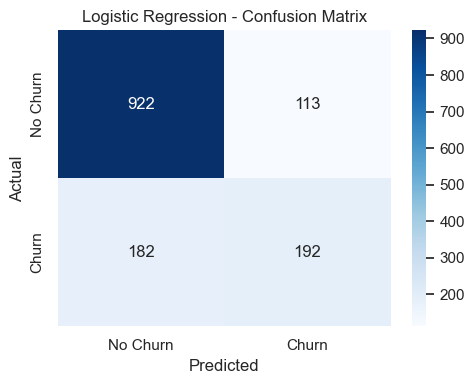

Saved to: C:\Users\Kaushlendra P Singh\Documents\Telecom-Customer-Churn-Analysis\04_Python\outputs\Model\random_forest_confusion_matrix.png


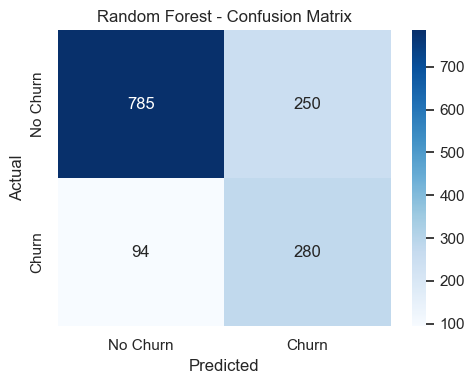

Saved to: C:\Users\Kaushlendra P Singh\Documents\Telecom-Customer-Churn-Analysis\04_Python\outputs\Model\gradient_boosting_confusion_matrix.png


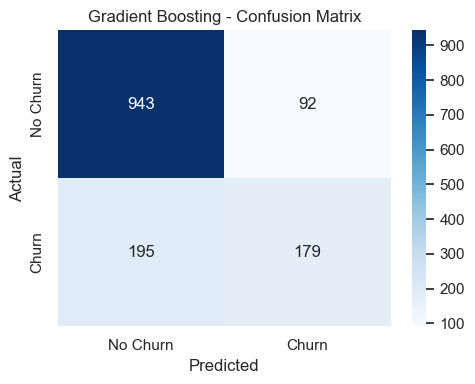

In [44]:
# ============================================================
# 7.10 CONFUSION MATRICES
# ============================================================

predictions = {
    "Logistic Regression": y_pred_lr,
    "Random Forest": y_pred_rf,
    "Gradient Boosting": y_pred_gb
}

for model_name, predictions_model in predictions.items():

    cm = confusion_matrix(
        y_test,
        predictions_model
    )

    plt.figure(figsize=(5, 4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["No Churn", "Churn"],
        yticklabels=["No Churn", "Churn"]
    )

    plt.title(f"{model_name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()

    safe_name = (
        model_name.lower()
        .replace(" ", "_")
        .replace("-", "_")
    )

    output_path = MODEL_DIR / f"{safe_name}_confusion_matrix.png"

    plt.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight"
    )

    print("Saved to:", output_path)

    plt.show()
    plt.close()


Saved to: C:\Users\Kaushlendra P Singh\Documents\Telecom-Customer-Churn-Analysis\04_Python\outputs\Model\roc_curve_model_comparison.png


<Figure size 800x600 with 0 Axes>

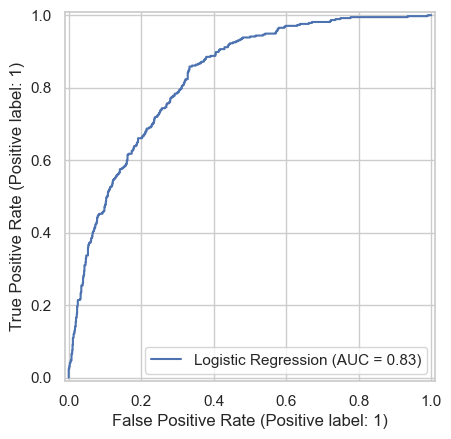

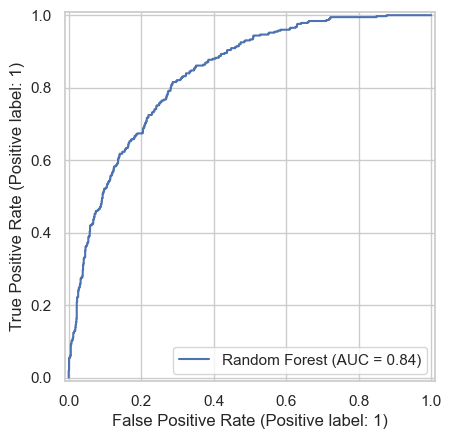

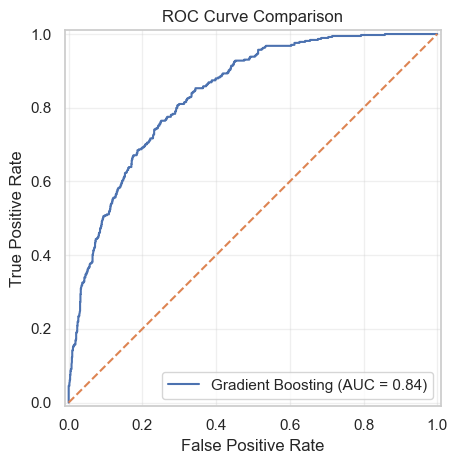

In [45]:
# ============================================================
# 7.11 ROC CURVE COMPARISON
# ============================================================

plt.figure(figsize=(8, 6))

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_lr,
    name="Logistic Regression"
)

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_rf,
    name="Random Forest"
)

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_gb,
    name="Gradient Boosting"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.grid(alpha=0.3)
plt.tight_layout()

roc_output_path = MODEL_DIR / "roc_curve_model_comparison.png"

plt.savefig(
    roc_output_path,
    dpi=300,
    bbox_inches="tight"
)

print("Saved to:", roc_output_path)

plt.show()
plt.close()


## 8. Model Interpretation


In [46]:
# ============================================================
# 8.1 Logistic Regression Coefficients
# ============================================================

feature_names = (
    lr_pipeline
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

coefficients = (
    lr_pipeline
    .named_steps["model"]
    .coef_[0]
)

coefficient_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

coefficient_df["Absolute_Coefficient"] = (
    coefficient_df["Coefficient"].abs()
)

coefficient_df = coefficient_df.sort_values(
    "Absolute_Coefficient",
    ascending=False
)

display(coefficient_df.head(15))


coefficient_output_path = MODEL_DIR / "logistic_regression_coefficients.csv"
coefficient_df.to_csv(coefficient_output_path, index=False)

print("Saved:", coefficient_output_path)


,Feature,Coefficient,Absolute_Coefficient
29,categorical__Contract_Two year,-1.617941,1.617941
12,categorical__InternetService_Fiber optic,0.912562,0.912562
28,categorical__Contract_One year,-0.857315,0.857315
3,numeric__TotalCharges,-0.567711,0.567711
13,categorical__InternetService_No,0.538385,0.538385
32,categorical__PaymentMethod_Electronic check,0.453650,0.453650
9,categorical__PhoneService_Yes,-0.438627,0.438627
16,categorical__OnlineSecurity_Yes,-0.435115,0.435115
27,categorical__StreamingMovies_Yes,0.380092,0.380092
30,categorical__PaperlessBilling_Yes,0.370623,0.370623


Saved: C:\Users\Kaushlendra P Singh\Documents\Telecom-Customer-Churn-Analysis\04_Python\outputs\Model\logistic_regression_coefficients.csv


## 9. Final Business Recommendations

Based on the descriptive analysis and predictive modeling, the analysis suggests several areas for customer-retention attention:

1. Monitor customers on month-to-month contracts.
2. Pay particular attention to customers in their first 12 months.
3. Review customers with high monthly charges.
4. Investigate customers using electronic-check payment.
5. Evaluate service adoption among customers without Tech Support, Online Security, or Online Backup.
6. Use churn-risk analysis as a prioritization tool rather than as proof that any single factor causes churn.

The findings represent patterns observed in the historical dataset and should not be interpreted as causal relationships.


## Final Output Export & Verification

Run this section **after all analysis, charts, KPI, segment analysis, and model cells**.

The notebook automatically saves outputs under:

```text
04_Python/
└── outputs/
    ├── KPI/
    ├── Charts/
    ├── Segment_Analysis/
    ├── Model/
    ├── Data_Quality/
    └── Insights/
```

The final cell also validates `all_segment_results` so an old Jupyter variable without `segment_type` does not cause a `KeyError`.


In [47]:
# ============================================================
# FINAL OUTPUT EXPORT & VERIFICATION
# ============================================================

# Rebuild/validate standardized segment results.
required_segment_columns = {
    "segment_type",
    "segment",
    "total_customers",
    "churned_customers",
    "churn_rate"
}

if (
    "all_segment_results" not in globals()
    or not required_segment_columns.issubset(all_segment_results.columns)
):
    segment_results = []

    for segment_type, column_name in segment_map.items():
        if column_name in df.columns:
            part = churn_rate_table(df, column_name)
            part.insert(0, "segment_type", segment_type)
            segment_results.append(part)

    if not segment_results:
        raise ValueError("No segment results could be generated.")

    all_segment_results = pd.concat(
        segment_results,
        ignore_index=True
    )

# Export segment outputs.
all_segment_results.to_csv(
    SEGMENT_DIR / "churn_rate_by_segment.csv",
    index=False
)

tenure_churn = churn_rate_table(df, "TenureCohort")

tenure_churn.to_csv(
    SEGMENT_DIR / "churn_rate_by_tenure_cohort.csv",
    index=False
)

# ------------------------------------------------------------
# Business insights
# ------------------------------------------------------------
insights = [
    f"Overall churn rate: {churn_rate:.2f}% "
    f"({int(churned_customers):,} of {int(total_customers):,} customers)."
]

for seg_type in [
    "Contract",
    "Tenure Cohort",
    "Internet Service",
    "Payment Method",
    "Tech Support"
]:
    part = all_segment_results[
        all_segment_results["segment_type"].eq(seg_type)
    ]

    if not part.empty:
        top = part.sort_values(
            "churn_rate",
            ascending=False
        ).iloc[0]

        insights.append(
            f"Highest churn segment for {seg_type}: "
            f"{top['segment']} ({top['churn_rate']:.2f}%)."
        )

if "churned_monthly_revenue" in globals():
    insights.append(
        f"Churned monthly revenue: "
        f"${float(churned_monthly_revenue):,.2f}; "
        f"revenue at risk: {float(revenue_at_risk):.2f}%."
    )

insights_output_path = INSIGHTS_DIR / "business_insights.txt"

insights_output_path.write_text(
    "\n".join(
        f"{i + 1}. {text}"
        for i, text in enumerate(insights)
    ),
    encoding="utf-8"
)

print("Saved:", insights_output_path)

# ------------------------------------------------------------
# Final folder verification
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("FINAL OUTPUT STRUCTURE")
print("=" * 70)

for folder in [
    KPI_DIR,
    CHART_DIR,
    SEGMENT_DIR,
    MODEL_DIR,
    DATA_QUALITY_DIR,
    INSIGHTS_DIR
]:
    print(f"\n[{folder.relative_to(PROJECT_DIR)}]")

    files_found = sorted(
        file for file in folder.iterdir()
        if file.is_file()
    )

    if files_found:
        for file in files_found:
            print(" -", file.name)
    else:
        print(" - No files found")

print("\nProject output generation completed successfully.")


Saved: C:\Users\Kaushlendra P Singh\Documents\Telecom-Customer-Churn-Analysis\04_Python\outputs\Insights\business_insights.txt

FINAL OUTPUT STRUCTURE

[04_Python\outputs\KPI]
 - business_kpis.csv

[04_Python\outputs\Charts]
 - 01_churn_distribution.png
 - 02_Tenure_distribution.png
 - 03_Monthly_Charges_vs_Churn.png
 - 04_Contract_Type_vs_Churn.png
 - 05_Customer_Count_by_Gender_and_Churn.png
 - 06_Churn_rate_by_Senior_Citizen.png
 - 07_Churn_rate_by_Internet_service.png
 - 08_Churn_rate_by_Payment_Method_and_Churn.png
 - 09_churn_rate_by_payment_method.png
 - 09_Tenure_&_Monthly_Charges_vs_Churn.png
 - 10_Churn_rate_by_Tenure_Cohort.png

[04_Python\outputs\Segment_Analysis]
 - churn_rate_by_segment.csv
 - churn_rate_by_tenure_cohort.csv

[04_Python\outputs\Model]
 - gradient_boosting_confusion_matrix.png
 - logistic_regression_coefficients.csv
 - logistic_regression_confusion_matrix.png
 - model_comparison.csv
 - model_metrics.csv
 - random_forest_confusion_matrix.png
 - roc_curve_mo

## Project Run Complete

After **Run All Cells**, verify the `04_Python/outputs/` folders before committing the project to GitHub.

Expected key files include:

- `KPI/business_kpis.csv`
- `Charts/*.png`
- `Segment_Analysis/churn_rate_by_segment.csv`
- `Segment_Analysis/churn_rate_by_tenure_cohort.csv`
- `Model/model_metrics.csv`
- `Model/model_comparison.csv`
- `Model/*_confusion_matrix.png`
- `Model/roc_curve_model_comparison.png`
- `Model/logistic_regression_coefficients.csv`
- `Data_Quality/data_quality_report.csv`
- `Insights/business_insights.txt`


# 9. Final Project Submission Checklist

Before uploading to GitHub:

1. Confirm `01_Dataset/telco_data.csv` exists locally.
2. Restart the Jupyter kernel.
3. Run **Run All Cells** from the beginning.
4. Confirm there are no red/error cells.
5. Confirm these output folders contain files:
   - `04_Python/outputs/KPI`
   - `04_Python/outputs/Charts`
   - `04_Python/outputs/Segment_Analysis`
   - `04_Python/outputs/Model`
   - `04_Python/outputs/Data_Quality`
   - `04_Python/outputs/Insights`
6. Confirm `business_insights.txt` is generated.
7. Save/export the notebook as `Telecom_Customer_Churn_Analysis.ipynb`.
8. Keep `telco_data.csv` out of GitHub if you are using the recommended `.gitignore`.
9. Commit the notebook, Python script, requirements, README and documentation.
